<a href="https://colab.research.google.com/github/JordanBaker78/Data201_JordanBaker/blob/main/Final_Project_Data201_Jordan_Baker.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Final Project 2: Decision Trees and Employee Salaries

## DATA 201 Spring 2026

## Jordan Baker

## Introduction

### Dataset: Employee Salaries - 2023
link: https://data.montgomerycountymd.gov/Government/Employee-Salaries-2023/iv8c-428b/about_data

Description: Annual salary information, including gross pay and overtime pay for all active, permanent employees of Montgomery County, MD, paid in calendar year 2023.


I will be using this dataset to predict an employee's salary based on factors like gender and department. This prediction is important because it will determine what departments get paid more and less, and if there is a gender wage gap in Montgomery County Employment. Some limitations include a lack of data in some columns and possible visulizations *may* be limited.


### Dataset Overview:
This dataset includes over 10 thousand rows and 8 columns of data. The variables include: 'Department, Department Name, Division, Gender, Base Salary, Overtime Pay, Longevity Pay, and Grade. The tables below describe each variable: (Variable name, description, and example)
|Department    |Department Name |Division |Gender |
| :------------: | :--------------: | :-------: | :-----: |
| Department Code for assigned employee |  Department Name for assigned empolyee| Division of the Department | Gender/Sex |
| 'ABS'  | 'Alcohol Beverage Services'  | 'ABS 85 Administration' | 'F' |


|Base_Salary    |Overtime_Pay |Longevity_Pay |Grade |
| :------------: | :--------------: | :-------: | :-----: |
| Annual base salary for employee | Overtime pay the employee received | Longevity pay the employee received |	Assigned grade for the employee |
| '`$78,947`' | '`$456.68`' | '`$6257.7`' | '`$16`'|

All missing values will be removed and the data will be split 75/25 for the train/test split.

## Exploratory Data Analysis:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor


In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/JordanBaker78/Data201_JordanBaker/refs/heads/main/Employee_Salaries_-_2023_20260512.csv")
df.head()

In [ ]:
df['Base_Salary'] = df['Base_Salary'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
df['Base_Salary'] = pd.to_numeric(df['Base_Salary'])
df['Overtime_Pay'] = df['Overtime_Pay'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
df['Overtime_Pay'] = pd.to_numeric(df['Overtime_Pay'])
df['Longevity_Pay'] = df['Longevity_Pay'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
df['Longevity_Pay'] = pd.to_numeric(df['Longevity_Pay'])
df.head()

#### Visulization 1: Historgram

In [ ]:
sns.histplot(data=df, x='Base_Salary', bins=50, kde=True)
plt.title('Distribution of Employee Base Salary (2023)')
plt.xlabel('Base Salary ($)')
plt.ylabel('Number of Employees')
plt.grid(True)
plt.figure(figsize=(10, 6))
plt.show()

This histogram shows the distribution of employees' base salaries. The distribution is slightly skewed to the right, with a small percentage of employees earning a base salary of over `$150,000` and very few employees earning over `$200,000`. The majority of employees earn a base salary of around `$75,000`.

#### Visulization 2: Barplot

In [ ]:
sns.barplot(data=df.sort_values(by='Base_Salary', ascending=True), x='Base_Salary', y='Department_Name')
plt.title('Base Salary by Department')
plt.xlabel('Base Salary ($)')
plt.ylabel('Department')
plt.show()

This Barplot shows the Base Salaries by Department, and we can see that the Office of Intergovernmental Relations Department has the highest base salaries, while the Alcohol Beverage Services and the Department of Public Libraries have the lowest salaries.

## Decision Tree Analysis


In [ ]:
X = df.drop('Base_Salary', axis=1)
y = df['Base_Salary']

# Handle categorical features by creating dummy variables (one-hot encoding)
X = pd.get_dummies(X, columns=['Department', 'Department_Name', 'Division', 'Gender', 'Grade'], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f"Dataset features: {list(X.columns)}")
print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

In [ ]:
dt_model = DecisionTreeRegressor(max_depth=3, random_state=42)
dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)

In [ ]:
dt_mse = mean_squared_error(y_test, dt_predictions)
dt_r2 = r2_score(y_test, dt_predictions)

print("--- Decision Tree Regressor Metrics ---")
print(f"Mean Squared Error (MSE): {dt_mse:.3f}")
print(f"R-squared (R2) Score: {dt_r2:.3f}")


dt_results = {'MSE': dt_mse, 'R2': dt_r2, 'Model': 'Decision Tree'}

--- Decision Tree Structure Visualization ---


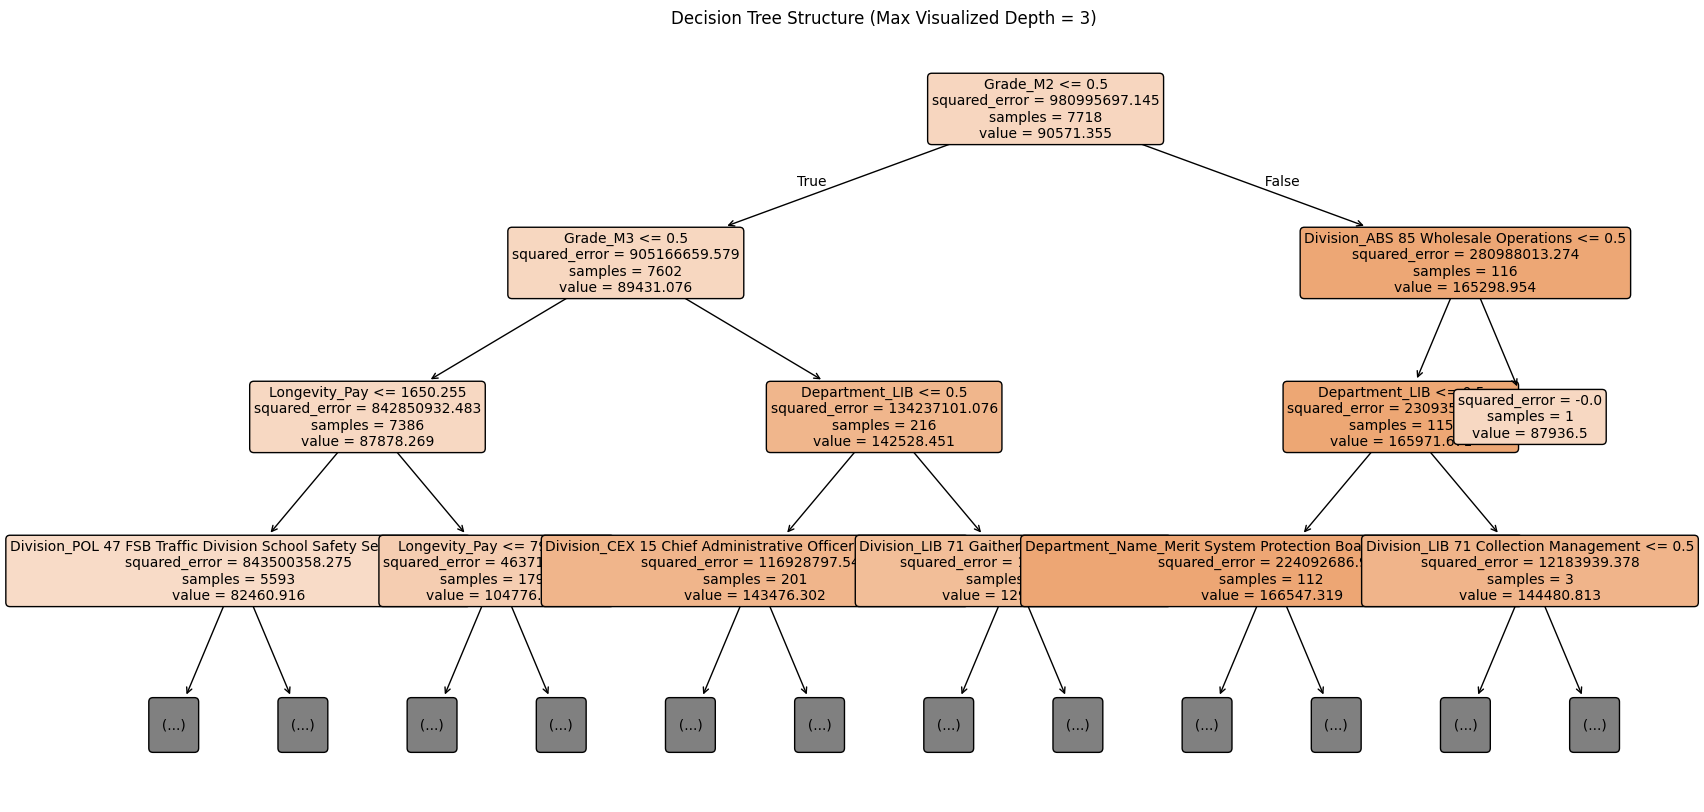

In [49]:
from sklearn.tree import plot_tree

print("--- Decision Tree Structure Visualization ---")

# Set the maximum depth to visualize for readability
plt.figure(figsize=(20, 10))
plot_tree(
    dt_model,
    max_depth=3,
    feature_names=X_train.columns.tolist(),
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title(f"Decision Tree Structure (Max Visualized Depth = 3)")
plt.show()


With an MSE of over 700 million and an R2 score of only 0.237, this Decision Tree, with a max_depth of 3, is a really poor regression model. This Decision Tree used the "Grade" variable as its root node, which is probably where the main issues come from. The values in the column of data are inconsistent, and even after research, I am unsure of what the values actually mean in context, and I don't think the model understands either. At the very least, I don't think this model is a victim of overfitting, with a max depth of only 3. What is interesting is the variables the model decided to choose as splits after the root node. It chose two separate departments and longevity pay, which is likely another reason the MSE score is so high. I don't believe those specific variables are ones that most people would choose as nodes for the tree.


This model predicts that if an employee has a grade of M2 or worse, a grade of M3 or worse, and a longevity pay of over 1650.26, their predicted salary will be about $104,777.


In [ ]:
dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)

In [ ]:
dt_mse = mean_squared_error(y_test, dt_predictions)
dt_r2 = r2_score(y_test, dt_predictions)

print("--- Decision Tree Regressor Metrics ---")
print(f"Mean Squared Error (MSE): {dt_mse:.3f}")
print(f"R-squared (R2) Score: {dt_r2:.3f}")


dt_results = {'MSE': dt_mse, 'R2': dt_r2, 'Model': 'Decision Tree'}

In [ ]:
from sklearn.tree import plot_tree

print("--- Decision Tree Structure Visualization ---")

# Set the maximum depth to visualize for readability
plt.figure(figsize=(20, 10))
plot_tree(
    dt_model,
    max_depth=3,
    feature_names=X_train.columns.tolist(),
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title(f"Decision Tree Structure (Max Visualized Depth = 3)")
plt.show()


This model with a max_depth of 5 is a little better, with an improved MSE score and R2 score, but this still cannot be considered a "good" model since the MSE score is still in the hundreds of millions. Unfortunately, with this dataset, there are only 8 variables, and I would say only 3 of them are usable variables for any regression or predictive models. Maybe it is worth considering using a heavily edited dataframe that only contains the usable variables to drastically improve the model.

##Random Forest Regressor

In [ ]:
rf_model = RandomForestRegressor(n_estimators=150, max_depth=12, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

In [ ]:
# Calculate metrics
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

print("--- Random Forest Regressor Metrics ---")
print(f"Mean Squared Error (MSE): {rf_mse:.3f}")
print(f"R-squared (R2) Score: {rf_r2:.3f}")

# Store results for comparison
rf_results = {'MSE': rf_mse, 'R2': rf_r2, 'Model': 'Random Forest'}

In [ ]:
# Select a single test sample to observe
test_sample_index = 12
sample_features = X_test.iloc[test_sample_index]
sample_true_value = y_test.iloc[test_sample_index]

# Get predictions from every individual tree in the Random Forest
tree_predictions = []
for tree in rf_model.estimators_:
    # Reshape the single sample to match the model's expected input (1, n_features)
    prediction = tree.predict(sample_features.to_frame().T)
    tree_predictions.append(prediction[0])

# Convert to Series for easy calculation
tree_predictions_series = pd.Series(tree_predictions)

print("--- Random Forest Prediction Distribution ---")
print(f"Sample True Value (y_test): {sample_true_value:.3f}")
print(f"Random Forest Aggregate Prediction: {rf_predictions[test_sample_index]:.3f}")
print(f"Prediction Standard Deviation: {tree_predictions_series.std():.3f}")


# Plot the distribution
plt.figure(figsize=(10, 6))
sns.histplot(tree_predictions_series, kde=True, bins=15, color='lightblue')
plt.axvline(rf_predictions[test_sample_index], color='red', linestyle='--', linewidth=2, label='Aggregate RF Prediction')
plt.axvline(sample_true_value, color='orange', linestyle='-', linewidth=2, label='True Value')
plt.title(f'Distribution of Predictions from {len(rf_model.estimators_)} Random Forest Trees')
plt.xlabel('Individual Tree Predicted Value (Salary)')
plt.ylabel('Frequency (Number of Trees)')
plt.legend()
plt.show()

After testing out some different values for max_depth, I settled on 12 because the model returned an R2 value of 0.653, which is the best R2 value I've seen so far. Unfortunately, the MSE score is still way too high, and a max_depth of 12 likely means overfitting, so this is still a very poor model for prediction. From the visualization, we can see an extremely spread distribution and high standard deviation, and even though I expected the prediction value and true value to be even further apart, this specific sample is still not an accurate prediction.

##Gradient Boosting Regressor

In [ ]:
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42)
gb_model.fit(X_train, y_train)

gb_predictions = gb_model.predict(X_test)

In [ ]:
gb_mse = mean_squared_error(y_test, gb_predictions)
gb_r2 = r2_score(y_test, gb_predictions)

print("--- Gradient Boosting Regressor Metrics ---")
print(f"Mean Squared Error (MSE): {gb_mse:.3f}")
print(f"R-squared (R2) Score: {gb_r2:.3f}")

gb_results = {'MSE': gb_mse, 'R2': gb_r2, 'Model': 'Gradient Boosting'}


While it is clear that, after all the boosting, the model may still not be very accurate based on the ridiculously high MSE score, we can see that the R2 is greatly improved, all the way up to 0.771, which is pretty good.

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, gb_predictions, alpha=0.6, color='orange', label='Predicted vs. Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction Line')
plt.title('Gradient Boosting: Actual vs. Predicted Employee Salaries')
plt.xlabel('Actual Target Values (Employee Salaries)')
plt.ylabel('Predicted Target Values (Employee Salaries)')
plt.legend()
plt.show()

##Feature Importance

In [ ]:
# Access the feature importances from the trained Gradient Boosting model
importances = gb_model.feature_importances_

# Get the feature names
feature_names = X_train.columns

# Create a Series for easy sorting and plotting
feature_importance_series = pd.Series(importances, index=feature_names)

# Sort the features by importance in descending order
sorted_importances = feature_importance_series.sort_values(ascending=False)

print("--- Gradient Boosting Feature Importance Scores ---")
print(sorted_importances.to_markdown(numalign="left", stralign="left", floatfmt=".4f"))

There are so many individual features that most of them have an 'importance score' of 0. Surprisingly, the most important feature is longevity pay, and the next highest are Grade_M2 and Grade_M3. (I am unsure of what this actually means in context, and I couldn't find an explanation.)

##Model Comparison

In the end, the Gradient Booster was the best model, returning the best R2 score and the lowest MSE score (even though it was still in the hundreds of millions). Personally, though, I think the easiest model to explain was the initial Tree model, despite it being the least effective model, because it is the easiest to understand. In the real world, I would use the Gradient Booster Regressor because it was the best, as long as I had the resources (time and proper equipment) to do so. If I had a time constraint, I might use the Random Forest Regression or even just the Decsion Tree, becuase it is less complicated, but If I want the best results, I would use the Gradient Booster.